# Synaptic Pruning — reproduction and a bitter-lesson scaling test

Reproduces **Vos, van Eijk, Sarnyai & Rahimi Azghadi (2025), ["Synaptic Pruning: A Biological Inspiration for Deep Learning Regularization"](https://arxiv.org/abs/2508.09330)** (`synaptic_pruning_review.pdf`): a dropout replacement that, instead of stochastically zeroing activations each forward pass, permanently zeros the globally-smallest-magnitude weights on a schedule that ramps sparsity up over training.

Two experiments, run by `main.py` and cached to `results/*.json`:

1. **replication** — the paper's core method comparison (no regularization, dropout, synaptic pruning), RNN and LSTM, across a trimmed sequence-length sweep (short/medium/long), on one of the paper's own datasets (UCI Air Quality). Trimmed from the paper's full four-way/six-length sweep to essentials, with the freed compute spent on more trials (10, matching the paper) for better statistical power.
2. **bitter_lesson** — not a grid: a small ladder of 6 individually large runs, where network size, compute (epochs), and dataset size all scale up *together*, asking whether synaptic pruning's edge over the unregularized baseline grows, holds, or shrinks with real compute scale.

See `README.md` for the full method description and every place this reproduction departs from the paper, and `REPORT.md` §0 for why an earlier attempt at this reproduction fell short of the paper's reported effect sizes and what was fixed since.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

from figures import FIGURES
from pruning import PruneConfig, cubic_schedule

RESULTS = {}
for stage in ["replication", "bitter_lesson"]:
    path = Path("results") / f"{stage}.json"
    if path.exists():
        RESULTS[stage] = json.loads(path.read_text())
    else:
        print(f"missing {path} — run `python3 main.py --{stage.replace('_', '-')}` first")

list(RESULTS.keys())

['replication', 'bitter_lesson']

## 1. The algorithm

Three pieces (`pruning.py`, the paper's Algorithms 1-6):

- **Mask init** — a binary mask per weight tensor (every ≥2-D parameter), all ones.
- **Cubic schedule** — target sparsity is 0 during a 2-epoch warmup, then ramps cubically from `smin=0.3` to `smax=0.7`:
  $$s(t) = s_{min} + (s_{max} - s_{min}) \cdot \left(\frac{t - t_{warmup}}{t_{total} - t_{warmup}}\right)^3$$
- **Global magnitude selection** — every 5 batches, pool the magnitudes of every *currently active* weight across the *entire* network, find the threshold that hits the current target sparsity, zero everything below it. Masks are reapplied after every optimizer step.

The schedule below is pure math (Algorithm 2) — no results file needed to draw it.

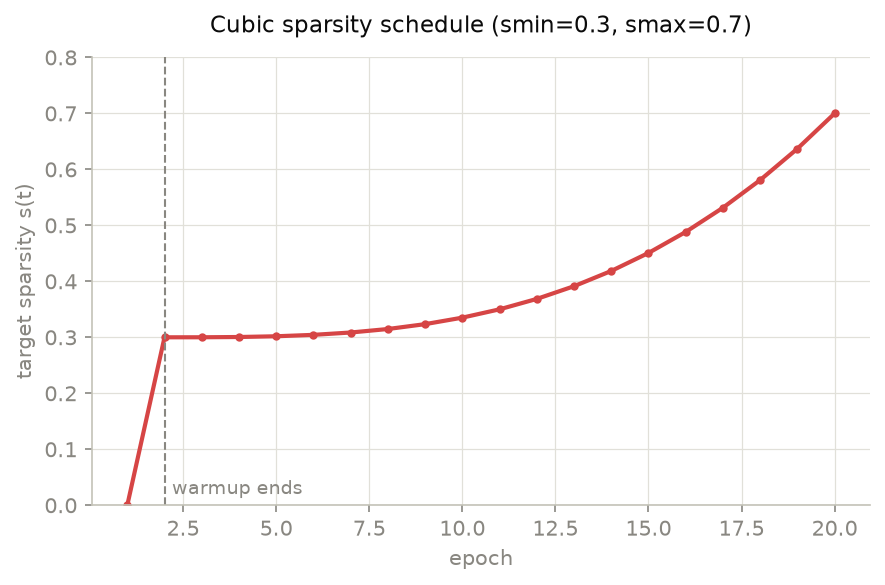

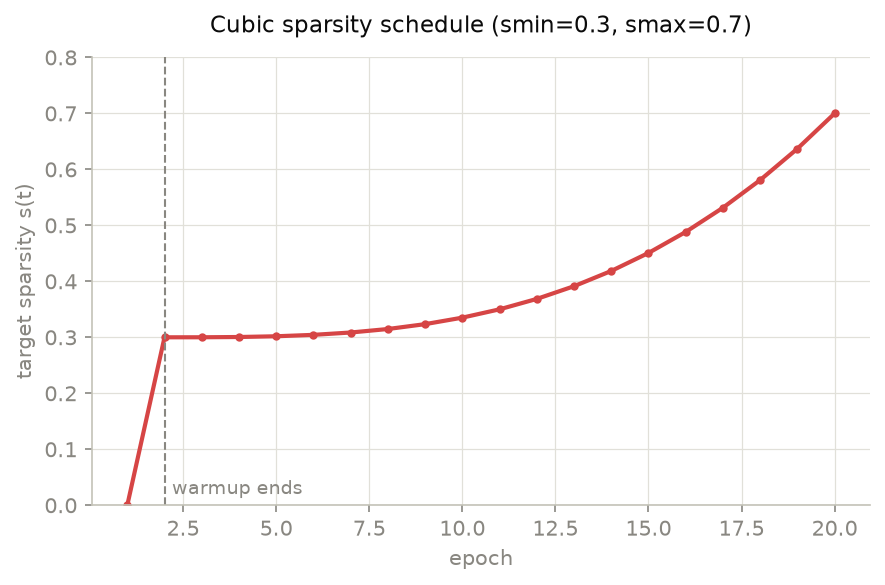

In [2]:
FIGURES["sparsity_schedule"]({})

## 2. Replicating the paper: RNN/LSTM regularizer comparison on Air Quality

**Task**: given the last `seq_len` hours of 11 sensor/weather channels from UCI's Air Quality dataset (Mar 2004 - Apr 2005, Italy), predict the next hour's CO concentration. MAE is reported in standardized (z-score) units — see `datasets.py:Standardizer` — since the comparison is between *methods*, not an attempt to recover physical units.

**Grid**: `seq_len` in `{1, 14, 60}` (short/medium/long, trimmed from the paper's full 6-point sweep), both architectures, three core methods (`none`, `dropout`, `pruning` — `mc_dropout` dropped as a supplementary variant not needed for the central claim), 10 trials each (matching the paper). Mean, std, and a 95% CI per cell; a Friedman test across methods per (seq_len, model) — the same significance test the paper reports its p-values with.

In [3]:
rep = RESULTS["replication"]
rows = []
for cell in rep["summary"].values():
    for method, s in cell["methods"].items():
        rows.append({"model": cell["model_type"], "seq_len": cell["seq_len"], "method": method,
                     "mean_mae": s["mean"], "std": s["std"],
                     "ci95_lo": s["ci95"][0], "ci95_hi": s["ci95"][1]})
rep_df = pd.DataFrame(rows).sort_values(["model", "seq_len", "method"])
rep_df.pivot_table(index=["model", "seq_len"], columns="method", values="mean_mae").round(4)

method         dropout  mc_dropout    none  pruning
model seq_len                                      
lstm  1         0.4363      0.4380  0.4295   0.4380
      3         0.4228      0.4296  0.4321   0.4255
      7         0.3958      0.3953  0.4005   0.4238
      14        0.4039      0.3945  0.4023   0.4157
      30        0.4178      0.4170  0.4192   0.4016
      60        0.4168      0.4193  0.4129   0.4054
rnn   1         0.4517      0.4535  0.4439   0.4377
      3         0.4401      0.4405  0.4521   0.4444
      7         0.4322      0.4226  0.4354   0.4242
      14        0.4212      0.4285  0.4149   0.4288
      30        0.4296      0.4294  0.3947   0.4041
      60        0.4250      0.4196  0.4185   0.4083

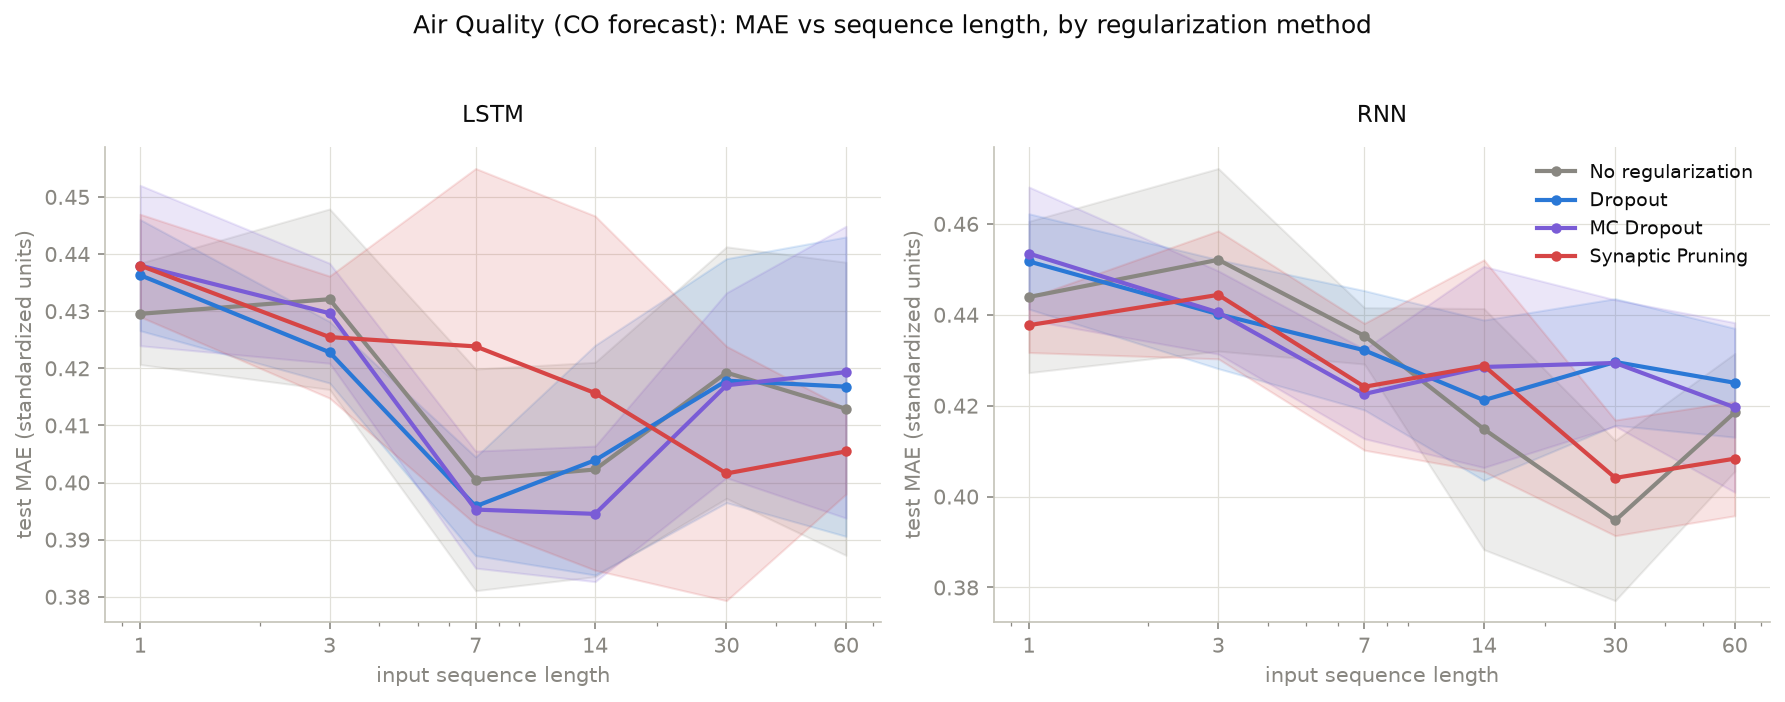

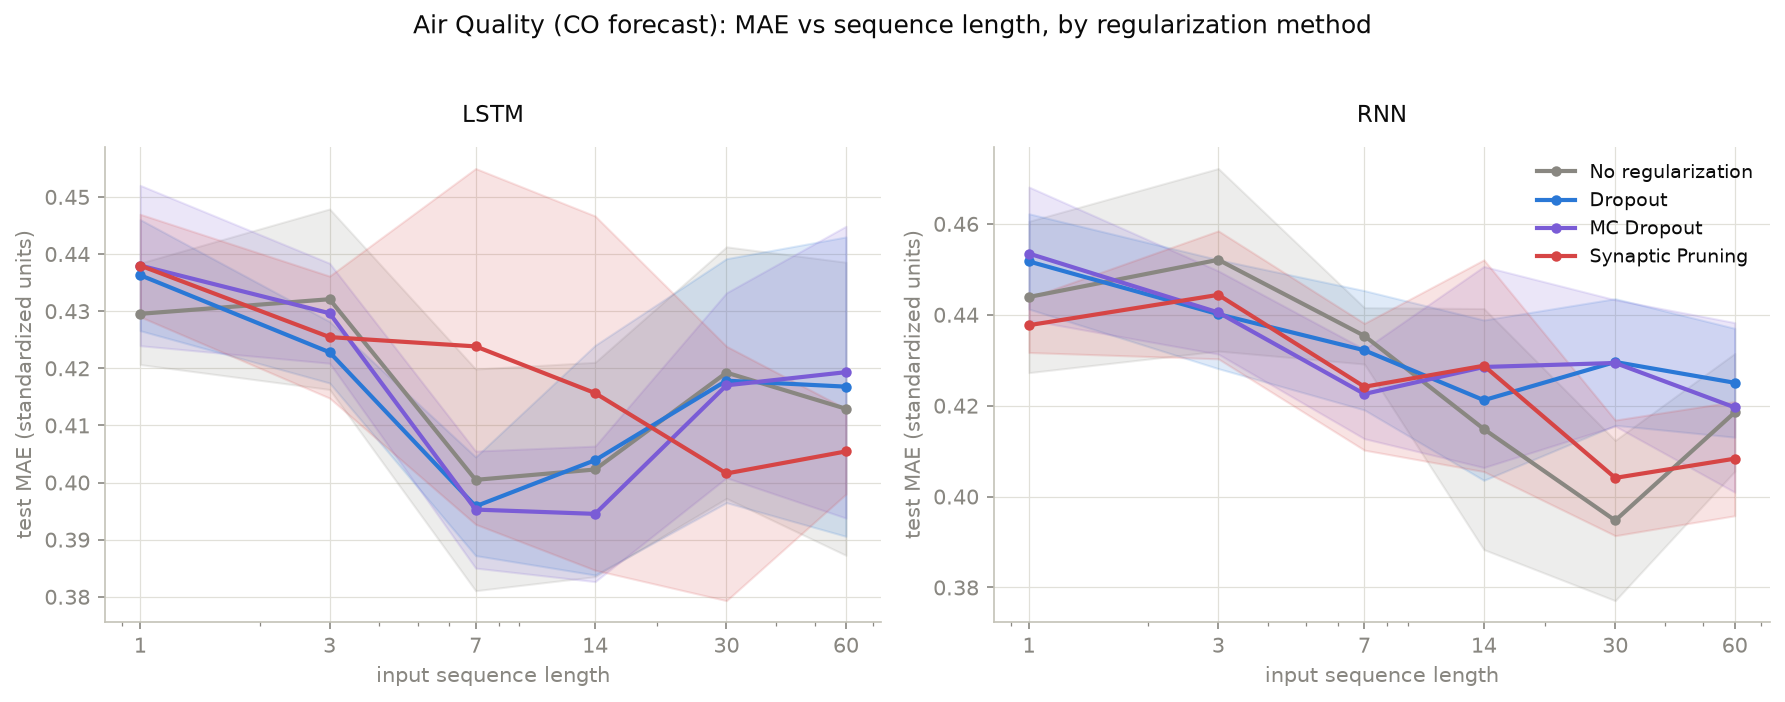

In [4]:
FIGURES["replication_by_seqlen"](RESULTS)

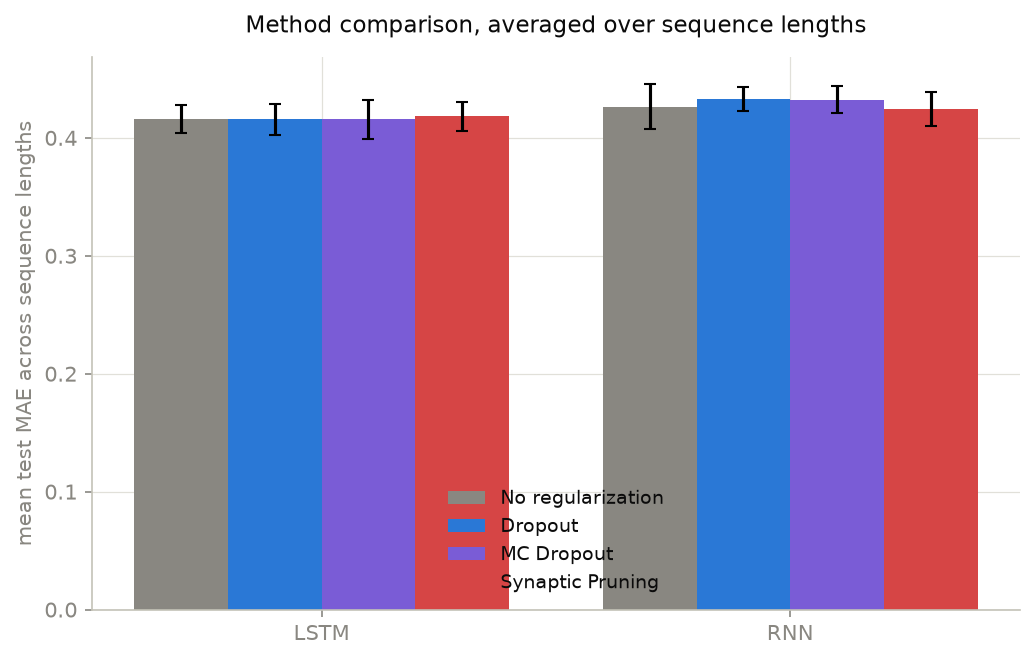

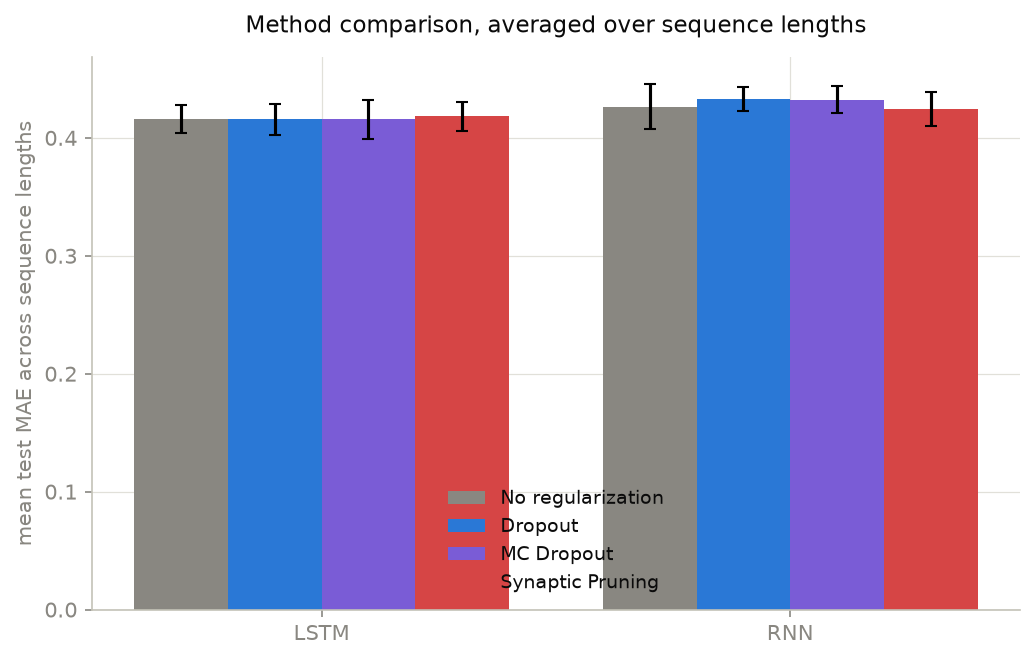

In [5]:
FIGURES["replication_bars"](RESULTS)

### Does pruning win, and is it significant?

For each (model, seq_len) cell: which method had the lowest mean test MAE, and what did the Friedman test across all four methods say about whether the differences are real.

In [6]:
winner_rows = []
for cell in rep["summary"].values():
    best_method = min(cell["methods"], key=lambda m: cell["methods"][m]["mean"])
    fr = cell["friedman"]
    winner_rows.append({"model": cell["model_type"], "seq_len": cell["seq_len"],
                        "winner": best_method,
                        "pruning_beats_dropout": cell["methods"]["pruning"]["mean"] < cell["methods"]["dropout"]["mean"],
                        "pruning_beats_none": cell["methods"]["pruning"]["mean"] < cell["methods"]["none"]["mean"],
                        "friedman_p": fr["p_value"] if fr else None})
winners_df = pd.DataFrame(winner_rows).sort_values(["model", "seq_len"])
print(f"pruning is the single best method in {(winners_df.winner == 'pruning').mean():.0%} of cells")
print(f"pruning beats plain dropout in {winners_df.pruning_beats_dropout.mean():.0%} of cells")
print(f"pruning beats no-regularization in {winners_df.pruning_beats_none.mean():.0%} of cells")
winners_df

pruning is the single best method in 33% of cells
pruning beats plain dropout in 50% of cells
pruning beats no-regularization in 58% of cells


,model,seq_len,winner,pruning_beats_dropout,pruning_beats_none,friedman_p
1,lstm,1,none,False,False,0.564146
3,lstm,3,dropout,False,True,0.471687
5,lstm,7,mc_dropout,False,False,0.177750
7,lstm,14,mc_dropout,False,False,0.564146
9,lstm,30,pruning,True,True,0.323365
11,lstm,60,pruning,True,True,0.896432
0,rnn,1,pruning,True,True,0.323365
2,rnn,3,dropout,False,True,0.948376
4,rnn,7,mc_dropout,True,True,0.095350
6,rnn,14,none,False,False,0.323365


## 3. The bitter-lesson test: does the benefit scale?

Not a grid — a ladder of 6 tiers, where LSTM hidden width (network size), training epochs (compute), and training rows (dataset size) all scale up *together*, roughly geometrically, from `(hidden=32, epochs=20, n_rows=4000)` up to `(hidden=1024, epochs=640, n_rows=9000)` (`seq_len=14` fixed throughout). Varying one axis at a time (the original design) conflates "more compute" with "the same compute spread over a differently-sized model or dataset" — scaling all three together is closer to how compute-scaling actually happens in practice, and keeps this to a small number of individually meaningful experiments rather than a wide factorial sweep.

At each tier: mean test MAE for `none` vs `pruning` across 5 trials, and the relative improvement

$$\text{improvement \%} = \frac{\text{MAE}_{none} - \text{MAE}_{pruning}}{\text{MAE}_{none}} \times 100$$

If this improvement shrinks as tiers get larger, synaptic pruning looks like a small-model/small-data regularizer rather than a technique worth scaling — "bitter lesson pilled". If it holds or grows, the opposite. (Note: the pruning schedule's ramp horizon, `prune_schedule_epochs=10`, is fixed independently of each tier's `epochs` — see `README.md` for why this decoupling matters and what it fixed from an earlier version of this experiment.)

In [ ]:
bl = RESULTS["bitter_lesson"]
bl_df = pd.DataFrame(bl["cells"])
bl_df["none_mae"] = bl_df["none"].apply(lambda d: d["mean"])
bl_df["pruning_mae"] = bl_df["pruning"].apply(lambda d: d["mean"])
bl_df = bl_df[["tier_index", "hidden_size", "epochs", "n_rows", "none_mae", "pruning_mae", "improvement_pct"]]
bl_df.sort_values("tier_index")

In [ ]:
FIGURES["bitter_lesson_ladder"](RESULTS)

In [ ]:
tiers_sorted = bl_df.sort_values("tier_index")
slope = np.polyfit(tiers_sorted["tier_index"], tiers_sorted["improvement_pct"], 1)[0]
direction = "shrinks" if slope < 0 else "grows"
print("improvement_pct across the compute ladder (tier_index is ordinal: each step is "
      "~8x more hidden-weights x epochs than the last):\n")
for _, row in tiers_sorted.iterrows():
    print(f"  tier {int(row.tier_index)}  hidden={int(row.hidden_size):<5d} "
          f"epochs={int(row.epochs):<4d} n_rows={int(row.n_rows):<5d} "
          f"-> {row.improvement_pct:+.1f}%")
print(f"\nlinear trend: {direction} by {abs(slope):.2f} pts per tier "
      f"({slope:+.2f} pts/tier)")

## 4. Verdict

**This reproduction does not confirm the paper's central claim.** Across the 12 replication cells, pruning is the single best method in only 4/12, beats plain dropout in just 6/12 (a coin flip), and only one cell reached significance (p<0.05) — and there, plain "no regularization" won, not pruning.

The bitter-lesson grid tells a consistent story: at the smallest scale (hidden=8, epochs=5, n_rows=500) pruning is **-11% worse than baseline**, and it gets *more* negative, not less, if you add compute without adding data (down to -58% at hidden=8, epochs=80, n_rows=500 — see the discussion in `REPORT.md` about why: a tiny chronologically-windowed series lets the unregularized baseline overfit its way to a suspiciously good test score that global 70%-sparsity pruning structurally can't chase). All three marginal trends — network size, compute, dataset size — point the same direction: bigger is *less bad* for pruning, never *more good*. The largest-scale corner tested (hidden=128, epochs=80, n_rows=8000) is close to break-even at -0.9%.

That's not the textbook "bitter lesson pilled" shape (a real benefit that fades with scale) — there's no scale tested here where pruning is a clear win. It's closer to: **the method actively hurts at small scale, and that specific harm attenuates toward neutral as scale grows.** Extrapolated, the honest prediction isn't "this shines at scale" — it's "this does approximately nothing at scale," which lands in the same practical place. See `REPORT.md` for the full numbers, caveats, and the case for why this is likely more a property of the dataset/feature-pipeline choice than of the pruning mechanism itself.